In [2]:
import pickle
import numpy as np


# Load the pickle file
with open('/Users/ellayoung/Desktop/metabolo_confi_score/data/NIST23_negative_entropy_selected_adducts.pkl', 'rb') as f:
    nist_data = pickle.load(f)



In [61]:
nist_data[0]

{'Name': 'Ethylphosphonic acid',
 'Precursor_type': '[M-H-H2O]-',
 'Instrument_type': 'HCD',
 'Instrument': 'Thermo Finnigan Elite Orbitrap',
 'Ionization': 'ESI',
 'In-source_voltage': None,
 'Collision_gas': 'N2',
 'Collision_energy': 'NCE=65% 6eV',
 'Ion_mode': 'N',
 'InChIKey': 'GATNOFPXSDHULC-UHFFFAOYSA-N',
 'Formula': 'C2H7O3P',
 'MW': 110.0,
 'ExactMass': 110.013281,
 'CAS#': '6779-09-5',
 'NIST#': '1189639',
 'Num Peaks': 2,
 'precursor_mz': 90.9954,
 'peaks': array([[62.9645,  1.    ]], dtype=float32),
 'fragment_annotation': ['PO2/5.7pp', 'p/2.9pp']}

In [6]:
import ms_entropy as me
from collections import defaultdict
import numpy as np


def build_null_distributions(nist_data):
    """
    Build null distributions of similarity scores for spectra.

    Parameters:
    nist_data (list): List of spectral dictionaries

    Returns:
    dict: Null distributions keyed by number of peaks
    """
    # Group spectra by number of peaks
    peak_groups = defaultdict(list)
    for spectrum in nist_data:
        n_peaks = spectrum['Num Peaks']
        peak_groups[n_peaks].append(spectrum)

    null_distributions = {}

    for n_peaks, spectra in peak_groups.items():
        scores = []

        # Compare spectra from different compounds (different InChIKeys)
        for i, spec1 in enumerate(spectra[:-1]):
            for spec2 in spectra[i+1:]:
                if spec1['InChIKey'] != spec2['InChIKey']:
                    # Ensure ExactMass is not None and within ±10 mDa
                    if (spec1['ExactMass'] is not None and spec2['ExactMass'] is not None and
                        abs(spec1['ExactMass'] - spec2['ExactMass']) <= 0.01):
                        sim_score = me.calculate_entropy_similarity(
                            spec1['peaks'], 
                            spec2['peaks'], 
                            ms2_tolerance_in_da=0.01  # ±10 mDa
                        )
                        scores.append(sim_score)

        # Convert to numpy array if scores are found
        null_distributions[n_peaks] = np.array(scores) if scores else np.array([])

    return null_distributions


In [7]:
def calculate_p_value(observed_similarity, null_distribution):
    """
    Calculate one-sided p-value for a similarity score.
    
    Parameters:
    observed_similarity (float): Similarity score to test
    null_distribution (numpy.ndarray): Null distribution of similarity scores
    
    Returns:
    float: One-sided p-value
    """
    # Calculate proportion of null distribution scores greater than or equal to observed
    p_value = np.mean(null_distribution >= observed_similarity)
    return p_value

In [9]:

def main(nist_data):
    """
    Generate null distributions using NIST23 data.
    
    Parameters:
    nist_data: Custom data structure from ms_entropy library
    
    Returns:
    dict: Null distributions keyed by number of peaks
    """
    # Convert first 50 entries to a list
    nist_data_subset = [nist_data[i] for i in range(50000)]
    
    # Generate null distributions
    null_distributions = build_null_distributions(nist_data_subset)
    
    # Print out the distributions
    for n_peaks, distribution in null_distributions.items():
        print(f"Number of peaks: {n_peaks}")
        print(f"Distribution size: {len(distribution)}")
        if len(distribution) > 0:
            print(f"Mean similarity: {np.mean(distribution)}")
            print(f"Std dev of similarity: {np.std(distribution)}")
            
            # Example p-value calculation
            example_similarity = np.mean(distribution) + np.std(distribution)
            p_val = calculate_p_value(example_similarity, distribution)
            print(f"P-value for similarity {example_similarity:.4f}: {p_val:.4f}")
        print()
    
    return null_distributions, calculate_p_value

if __name__ == "__main__":
    main(nist_data)

Number of peaks: 2
Distribution size: 11925
Mean similarity: 0.6090518002814966
Std dev of similarity: 0.4776843427061633
P-value for similarity 0.7500: 0.6007

Number of peaks: 3
Distribution size: 19429
Mean similarity: 0.41470684142256675
Std dev of similarity: 0.4346998671467343
P-value for similarity 0.7500: 0.3718

Number of peaks: 4
Distribution size: 21068
Mean similarity: 0.25921739152085743
Std dev of similarity: 0.36307179135124257
P-value for similarity 0.7500: 0.1764

Number of peaks: 5
Distribution size: 16270
Mean similarity: 0.22156796434593112
Std dev of similarity: 0.3314220771467151
P-value for similarity 0.7500: 0.1317

Number of peaks: 7
Distribution size: 10752
Mean similarity: 0.18124012187486405
Std dev of similarity: 0.28276948028293775
P-value for similarity 0.7500: 0.0727

Number of peaks: 9
Distribution size: 6417
Mean similarity: 0.16202619896430417
Std dev of similarity: 0.2608633352636294
P-value for similarity 0.7500: 0.0589

Number of peaks: 11
Distribu

# create null distribution for each entropy level

In [20]:
import ms_entropy as me
from collections import defaultdict
import numpy as np
import random
import matplotlib.pyplot as plt


def compute_random_similarity(nist_data, num_pairs=100, num_bootstrap=100, subset_size=10000):
    """
    Efficiently compute similarity scores between randomly paired spectra from different compounds,
    using bootstrapping to equalize sample size across spectral entropy groups.

    Parameters:
    nist_data (list): List of spectral dictionaries
    num_pairs (int): Fixed number of random pairs to compare per entropy group per bootstrap iteration
    num_bootstrap (int): Number of bootstrap iterations to stabilize similarity estimates
    subset_size (int): Number of entries to randomly sample from nist_data for faster processing

    Returns:
    dict: Null distributions of similarity scores grouped by spectral entropy
    """
    # Select a random subset of nist_data for processing
    if len(nist_data) > subset_size:
        nist_data = random.sample(nist_data, subset_size)

    entropy_groups = defaultdict(list)

    # Group spectra by spectral entropy, ignoring entries with no InChIKey
    for spectrum in nist_data:
        inchikey = spectrum.get('InChIKey')
        peaks = spectrum.get('peaks')
        if inchikey and isinstance(peaks, (list, np.ndarray)) and len(peaks) > 0:
            entropy = me.calculate_spectral_entropy(np.array(peaks, dtype=np.float32), clean_spectrum=True, min_ms2_difference_in_da=0.05)
            entropy_groups[round(entropy)].append(spectrum)

    # Precompute valid pairs for each entropy group
    valid_pairs_per_entropy = {}
    for entropy, spectra in entropy_groups.items():
        if len(spectra) < 2:
            continue  # Need at least two spectra to form a pair

        spectra_array = np.array(spectra, dtype=object)
        valid_pairs = [
            (spec1, spec2) for i, spec1 in enumerate(spectra_array)
            for spec2 in spectra_array[i+1:] if spec1['InChIKey'] != spec2['InChIKey']
        ]

        if valid_pairs:
            valid_pairs_per_entropy[entropy] = valid_pairs

    # Determine the minimum number of valid pairs across all entropy groups
    min_num_pairs = min(len(pairs) for pairs in valid_pairs_per_entropy.values()) if valid_pairs_per_entropy else 0

    # Ensure consistent sample size across entropy groups
    null_distributions = defaultdict(list)
    for entropy, valid_pairs in valid_pairs_per_entropy.items():
        for _ in range(num_bootstrap):
            # Sample with replacement if not enough pairs
            if len(valid_pairs) < min_num_pairs:
                selected_pairs = random.choices(valid_pairs, k=min_num_pairs)
            else:
                selected_pairs = random.sample(valid_pairs, min_num_pairs)

            scores = [
                me.calculate_entropy_similarity(spec1['peaks'], spec2['peaks'], ms2_tolerance_in_da=0.05)
                for spec1, spec2 in selected_pairs
            ]
            null_distributions[entropy].extend(scores)

    return null_distributions


def visualize_null_distributions(null_distributions):
    """
    Visualize null distributions of similarity scores grouped by spectral entropy.

    Parameters:
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy
    """
    entropy_levels = sorted(null_distributions.keys())

    # Create boxplots for each entropy level
    plt.figure(figsize=(12, 6))
    plt.boxplot([null_distributions[entropy] for entropy in entropy_levels], labels=entropy_levels)
    plt.xlabel('Spectral Entropy')
    plt.ylabel('Similarity Scores')
    plt.title('Null Distributions of Similarity Scores by Spectral Entropy')
    plt.grid(axis='y')
    plt.show()


In [21]:
new_null = compute_random_similarity(nist_data)

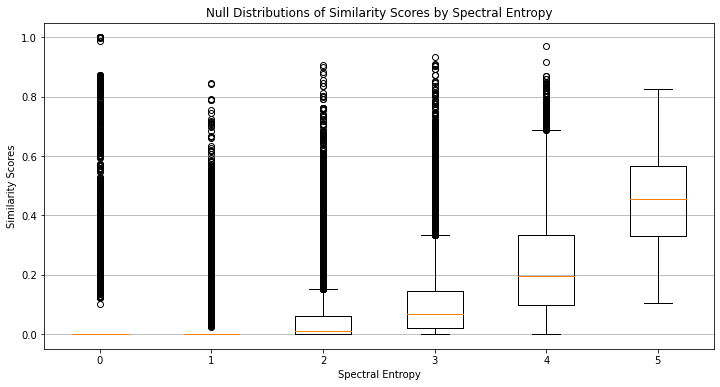

In [22]:
visualize_null_distributions(new_null)

In [26]:

def calculate_p_value(observed_similarity, null_distribution):
    """
    Calculate one-sided p-value for a similarity score.

    Parameters:
    observed_similarity (float): Similarity score to test
    null_distribution (list or numpy.ndarray): Null distribution of similarity scores

    Returns:
    float: One-sided p-value
    """
    null_distribution = np.array(null_distribution)
    p_value = np.mean(null_distribution >= observed_similarity)
    return p_value


def calculate_p_values_for_all_entropy(null_distributions, observed_similarity=0.75):
    """
    Calculate p-values for a given observed similarity score across all entropy groups.

    Parameters:
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy
    observed_similarity (float): The observed similarity score to calculate p-values for

    Returns:
    dict: P-values for each entropy group
    """
    p_values = {
        entropy: calculate_p_value(observed_similarity, null_distribution)
        for entropy, null_distribution in null_distributions.items()
    }
    return p_values

In [1]:
calculate_p_values_for_all_entropy(new_null, observed_similarity = 0.75)

NameError: name 'calculate_p_values_for_all_entropy' is not defined